# Battery Energy Storage System (BESS) Simulation

This notebook simulates various BESS duty cycles using the Tesla Model 3 LFP prismatic cell.

## BESS Applications
- **Frequency Regulation**: High-frequency cycling for grid ancillary services
- **Energy Time Shifting**: Solar self-consumption and arbitrage
- **Peak Shaving**: Commercial/industrial demand charge reduction
- **Capacity Firming**: PV output smoothing for renewable firming
- **Backup Power**: Emergency backup / black start capability
- **Renewable Shifting**: Weekly renewable energy storage

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model_library import run_drive_cycle, print_drive_cycle_report

## 1. Load Tesla Model 3 LFP Cell Design

In [2]:
manifest_path = Path("../cells/Tesla_Model3_Prismatic_160Ah_manifest.json")
material_path = Path("../materials")

with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)
    
    # Load material properties
    for component in ["separator", "electrolyte"]:
        material_name = cell_design_manifest["cell_design"][component]["material"]["type"]
        with open(material_path / f"{material_name}.json", "r") as mf:
            cell_design_manifest["cell_design"][component]["material"] = json.load(mf)

    for component in ["negative_electrode", "positive_electrode"]:
        material_name = cell_design_manifest["cell_design"][component]["coating"]["formulation"]["primary_active_material"]["name"]
        with open(material_path / f"{material_name}.json", "r") as mf:
            cell_design_manifest["cell_design"][component]["material"] = json.load(mf)

cell_design = cell_design_manifest["cell_design"]
cell_design["nominal_capacity"] = {"value": cell_design_manifest['kpis']['nominal_capacity']['value'], "unit": "Ah"}
cell_design["nominal_energy"] = {"value": cell_design_manifest['kpis']['nominal_energy']['value'], "unit": "Wh"}
cell_design["cell_volume"] = {"value": cell_design_manifest['kpis']['cell_volume']['value'], "unit": "L"}

print(f"Cell: {cell_design_manifest['metadata']['name']}")
print(f"Form factor: {cell_design['form_factor']}")
print(f"Capacity: {cell_design['nominal_capacity']['value']:.1f} Ah")
print(f"Energy: {cell_design['nominal_energy']['value']:.1f} Wh")
print(f"Nominal voltage: {cell_design_manifest['kpis']['nominal_voltage']['value']:.2f} V")
print(f"Voltage range: {cell_design['lower_voltage_cutoff']['value']:.2f} - {cell_design['upper_voltage_cutoff']['value']:.2f} V")

Cell: Tesla Model3 Prismatic 160Ah
Form factor: Prismatic
Capacity: 161.1 Ah
Energy: 515.5 Wh
Nominal voltage: 3.20 V
Voltage range: 2.50 - 3.65 V


## 2. Load BESS Duty Cycles

The BESS duty cycles are normalized power profiles (per-unit, -1 to +1).

**Sign Convention (per documentation):**
- **Frequency Regulation**: Positive = discharge, Negative = charge
- **All other cycles**: Positive = charge, Negative = discharge

Note: PyBaMM uses positive = discharge convention. We convert each cycle appropriately.

In [3]:
# Available BESS duty cycles
bess_cycles = {
    "Frequency Regulation": "BESS Frequency Regulation.csv",
    "Energy Time Shifting": "BESS Energy Time Shifting.csv",
    "Peak Shaving": "BESS Peak Shaving.csv",
    "Capacity Firming": "BESS Capacity Firming.csv",
    "Backup Power": "BESS Backup Power.csv",
    "Renewable Shifting": "BESS Renewable Shifting.csv",
}

# Sign convention per documentation:
# Frequency Regulation: positive=discharge, negative=charge (same as PyBaMM)
# All others: positive=charge, negative=discharge (opposite of PyBaMM)
cycles_with_discharge_positive = {"Frequency Regulation"}

# Load all cycles
drive_cycle_path = Path("../drive_cycles")
duty_cycles = {}

for name, filename in bess_cycles.items():
    df = pd.read_csv(drive_cycle_path / filename)
    duty_cycles[name] = df
    duration_hrs = df['Time_Minutes'].max() / 60
    sign_conv = "pos=discharge" if name in cycles_with_discharge_positive else "pos=charge"
    print(f"{name}: {len(df)} points, {duration_hrs:.1f} hours, power range [{df['Power_PerUnit'].min():.2f}, {df['Power_PerUnit'].max():.2f}] ({sign_conv})")

Frequency Regulation: 1440 points, 24.0 hours, power range [-0.92, 0.99] (pos=discharge)
Energy Time Shifting: 1440 points, 24.0 hours, power range [-0.90, 0.80] (pos=charge)
Peak Shaving: 1440 points, 24.0 hours, power range [-0.95, 0.40] (pos=charge)
Capacity Firming: 720 points, 12.0 hours, power range [-0.61, 0.09] (pos=charge)
Backup Power: 2880 points, 48.0 hours, power range [-0.90, 0.60] (pos=charge)
Renewable Shifting: 10080 points, 168.0 hours, power range [-0.40, 0.60] (pos=charge)


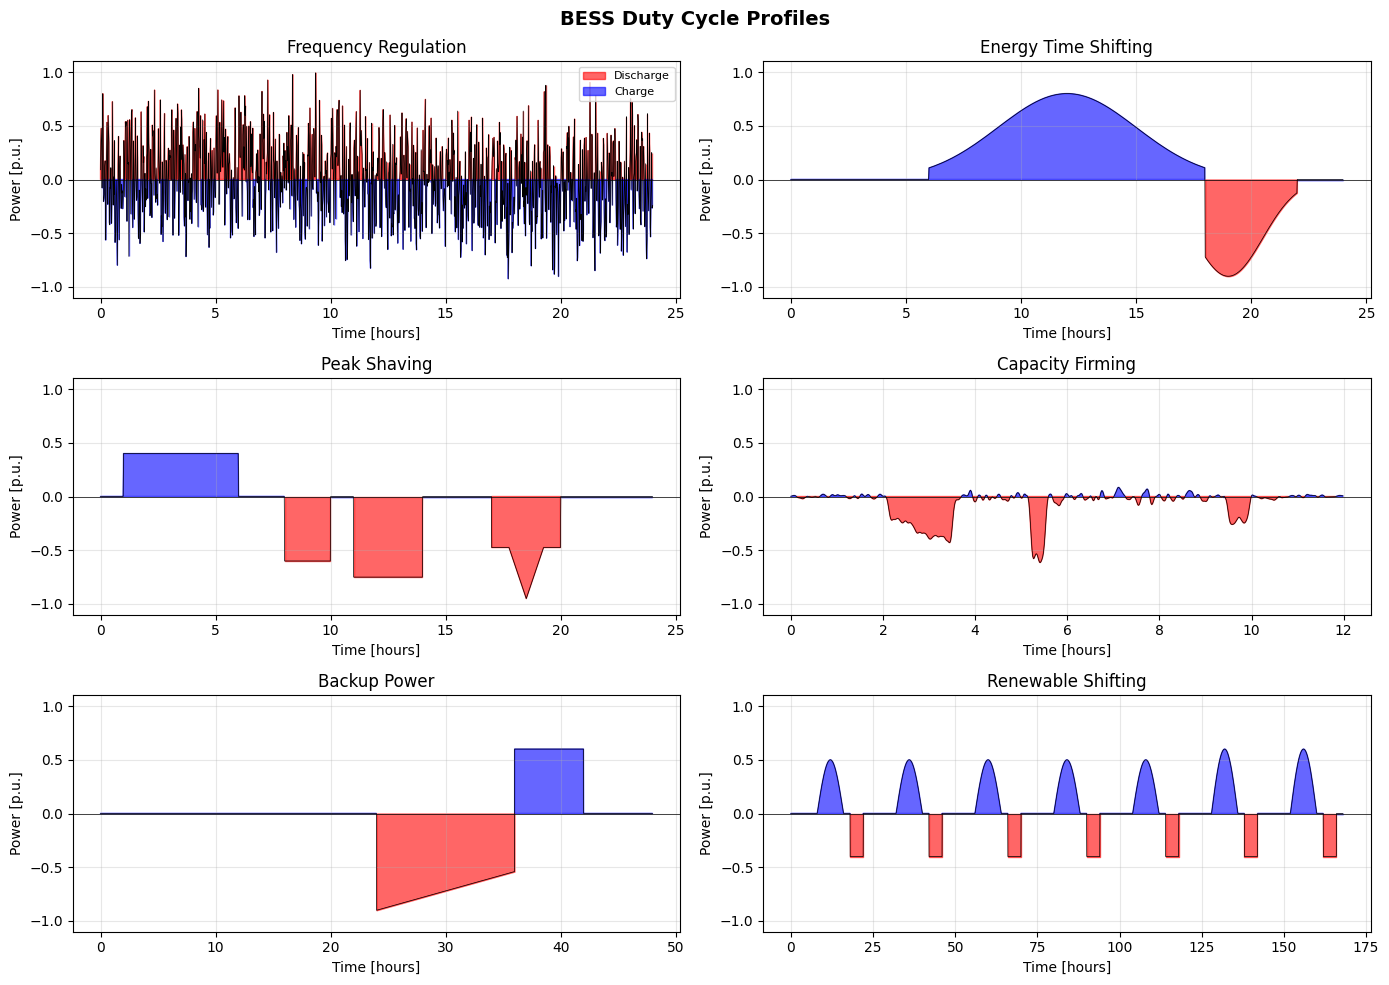

In [4]:
# Plot all duty cycles
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, df) in enumerate(duty_cycles.items()):
    ax = axes[idx]
    time_hrs = df['Time_Minutes'] / 60
    power = df['Power_PerUnit']
    
    # Sign convention differs by cycle
    if name in cycles_with_discharge_positive:
        # Positive = discharge (red), Negative = charge (blue)
        ax.fill_between(time_hrs, power, 0, where=(power >= 0), alpha=0.6, color='red', label='Discharge')
        ax.fill_between(time_hrs, power, 0, where=(power < 0), alpha=0.6, color='blue', label='Charge')
    else:
        # Positive = charge (blue), Negative = discharge (red)
        ax.fill_between(time_hrs, power, 0, where=(power >= 0), alpha=0.6, color='blue', label='Charge')
        ax.fill_between(time_hrs, power, 0, where=(power < 0), alpha=0.6, color='red', label='Discharge')
    
    ax.plot(time_hrs, power, 'k-', lw=0.5)
    ax.set_xlabel('Time [hours]')
    ax.set_ylabel('Power [p.u.]')
    ax.set_title(name)
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', lw=0.5)
    if idx == 0:
        ax.legend(loc='upper right', fontsize=8)

plt.suptitle('BESS Duty Cycle Profiles', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 3. BESS System Configuration

Configure a utility-scale BESS system using Tesla Model 3 LFP cells.

Example: 1 MWh system
- Cell energy: ~515 Wh
- Cells needed: ~1940 cells
- Configuration: e.g., 194S10P (194 series x 10 parallel)

In [ ]:
# BESS system parameters
cell_capacity_Ah = cell_design['nominal_capacity']['value']
cell_energy_Wh = cell_design['nominal_energy']['value']
cell_voltage_nom = cell_design_manifest['kpis']['nominal_voltage']['value']

# Power rating: 0.05C at 1.0 p.u. (conservative for high-cycling BESS applications)
# This ensures voltage stays within limits even for aggressive duty cycles
c_rate_for_1pu = 0.05  # C-rate at 1.0 per-unit power

# Target system size - 2 MWh utility-scale BESS
target_energy_kWh = 2000  # 2 MWh system

# Calculate pack configuration
cells_needed = (target_energy_kWh * 1000) / cell_energy_Wh

# Configuration for ~400V DC bus (typical for grid-tied inverter)
cells_series = 125  # 125 * 3.2V = 400V nominal
cells_parallel = int(np.ceil(cells_needed / cells_series))
total_cells = cells_series * cells_parallel

# Actual system specs
pack_capacity_Ah = cell_capacity_Ah * cells_parallel
pack_energy_kWh = (cell_energy_Wh * total_cells) / 1000
pack_voltage_nom = cell_voltage_nom * cells_series

# Max power at configured C-rate
max_power_kW = pack_energy_kWh * c_rate_for_1pu

print(f"=== BESS System Configuration ===")
print(f"Target: {target_energy_kWh} kWh ({target_energy_kWh/1000:.1f} MWh)")
print(f"\nPack configuration: {cells_series}S{cells_parallel}P ({total_cells} cells)")
print(f"Pack capacity: {pack_capacity_Ah:.1f} Ah")
print(f"Pack energy: {pack_energy_kWh:.1f} kWh ({pack_energy_kWh/1000:.2f} MWh)")
print(f"Pack voltage (nominal): {pack_voltage_nom:.0f} V")
print(f"\nPower rating at 1.0 p.u.: {max_power_kW:.1f} kW ({max_power_kW/1000:.2f} MW)")
print(f"Cell current at 1.0 p.u.: {c_rate_for_1pu * cell_capacity_Ah:.1f} A ({c_rate_for_1pu}C)")

## 4. Select and Run BESS Duty Cycle

Choose a duty cycle to simulate. For faster simulation, we'll use a subset of the data.

Duty cycle: Frequency Regulation
Duration: 120.0 min (2.00 hours)
Cell power range: -12852.5 to 12870.2 W
Pack power range: -411.3 to 411.8 kW
  (Positive = discharge, Negative = charge in PyBaMM)


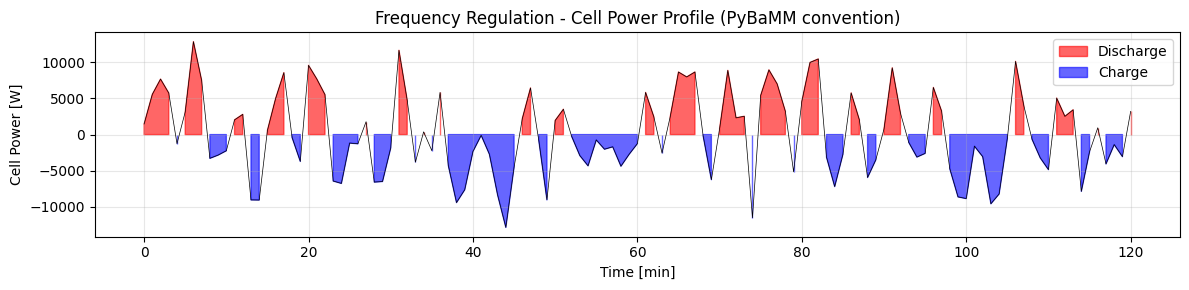

In [6]:
# Select duty cycle
selected_cycle = "Frequency Regulation"  # Change this to try different cycles

# Get duty cycle data
df = duty_cycles[selected_cycle].copy()

# For faster simulation, use first 2 hours (or full cycle if shorter)
max_duration_min = 120  # 2 hours
df = df[df['Time_Minutes'] <= max_duration_min].copy()

# Convert to simulation format
# Time in seconds, Power in Watts (at cell level)
time_s = df['Time_Minutes'].values * 60  # minutes to seconds

# Scale per-unit power to cell power
# PyBaMM convention: positive = discharge
# Convert based on duty cycle sign convention
if selected_cycle in cycles_with_discharge_positive:
    # Frequency Regulation: positive=discharge (same as PyBaMM), no negation needed
    cell_power_W = df['Power_PerUnit'].values * max_power_kW * 1000 / cells_parallel
else:
    # Other cycles: positive=charge (opposite of PyBaMM), negate
    cell_power_W = -df['Power_PerUnit'].values * max_power_kW * 1000 / cells_parallel

print(f"Duty cycle: {selected_cycle}")
print(f"Duration: {time_s[-1]/60:.1f} min ({time_s[-1]/3600:.2f} hours)")
print(f"Cell power range: {cell_power_W.min():.1f} to {cell_power_W.max():.1f} W")
print(f"Pack power range: {cell_power_W.min()*cells_parallel/1000:.1f} to {cell_power_W.max()*cells_parallel/1000:.1f} kW")
print(f"  (Positive = discharge, Negative = charge in PyBaMM)")

# Plot (show in PyBaMM convention for consistency with simulation)
fig, ax = plt.subplots(figsize=(12, 3))
ax.fill_between(time_s/60, cell_power_W, 0, where=(cell_power_W >= 0), alpha=0.6, color='red', label='Discharge')
ax.fill_between(time_s/60, cell_power_W, 0, where=(cell_power_W < 0), alpha=0.6, color='blue', label='Charge')
ax.plot(time_s/60, cell_power_W, 'k-', lw=0.5)
ax.set_xlabel('Time [min]')
ax.set_ylabel('Cell Power [W]')
ax.set_title(f'{selected_cycle} - Cell Power Profile (PyBaMM convention)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Configure simulation
config = {
    "ambient_temperature": 298.15,  # 25C
    "initial_temperature": 298.15,
    "initial_soc": 0.50,  # Start at 50% SOC for BESS (typical operating point)
    "upper_voltage_cutoff": cell_design["upper_voltage_cutoff"]["value"],
    "lower_voltage_cutoff": cell_design["lower_voltage_cutoff"]["value"],
    "contact_resistance": 0.0001,
    "total_heat_transfer_coefficient": 15,  # Containerized BESS cooling
    "cooling_surface_area": 0.05,  # Larger cooling area for BESS module
    "period": "10 second",  # Coarser resolution for longer cycles
    "min_soc": 0.10,  # 10% minimum SOC
    "max_soc": 0.90,  # 90% maximum SOC
    
    # Drive cycle (power profile)
    "drive_cycle": {
        "time_s": time_s,
        "power_W": cell_power_W,  # Positive = discharge in PyBaMM convention
        "label": selected_cycle,
    },
}

# Run simulation
print(f"Running {selected_cycle} simulation...")
result = run_drive_cycle(cell_design=cell_design, simulation_config=config)

Running Frequency Regulation simulation...

Building model parameters from manifest...

CAPACITY CALIBRATION
Target capacity: 161.10 Ah
Convergence tolerance: 0.010%
--------------------------------------------------------------------------------
Iteration  1: Capacity =  59.24 Ah, Error = 63.224%
Iteration  2: Capacity = 163.79 Ah, Error =  1.668%
Iteration  3: Capacity = 161.07 Ah, Error =  0.021%
Iteration  4: Capacity = 161.10 Ah, Error =  0.000%
--------------------------------------------------------------------------------
Converged after 4 iterations!

RUNNING DRIVE CYCLE
  Type: Power
  Power range: -12852.5 to 12870.2 W
  Label: Frequency Regulation
  Duration: 7200.0 s (120.0 min)
  Data points: 121
  Running simulation (initial SOC: 50%)...


2026-01-26 02:22:55.420 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Step([[     0.          1467.6096125]
 [    60.          5574.01675  ]
 [   120.          7684.410375 ]
 [   180.          5751.225375 ]
 [   240.         -1259.792225 ]
 [   300.          3141.425625 ]
 [   360.         12870.1791375]
 [   420.          7495.9248375]
 [   480.         -3289.636475 ]
 [   540.         -2843.3929375]
 [   600.         -2240.8836125]
 [   660.          2041.1211625]
 [   720.          2801.5072625]
 [   780.         -9044.083825 ]
 [   840.         -9061.8046875]
 [   900.           579.9555   ]
 [   960.          5015.0040875]
 [  1020.          8573.675475 ]
 [  1080.          -404.3578625]
 [  1140.         -3718.15915  ]
 [  1200.          9586.9866125]
 [  1260.          7711.7971625]
 [  1320.          5532.131075 ]
 [  1380.         -6431.0621   ]
 [  1440.         -6761.3145375]
 [  150

  Completed: 9 data points


In [8]:
# Print report
if result['success']:
    print_drive_cycle_report(result)
else:
    print(f"Simulation failed: {result.get('error', 'Unknown error')}")

DRIVE CYCLE SIMULATION REPORT

──────────────────────────────────────────────────────────────────────
SIMULATION SUMMARY
──────────────────────────────────────────────────────────────────────
  Duration:        77.4 s (1.3 min)
  Data points:     9
  Voltage:         1.500 - 3.386 V
  Current:         433.4 - 4122.9 A
  Power:           1467.6 - 6184.3 W
  Temperature:     25.0 - 50.4 °C
  Temp rise:       25.4 °C

──────────────────────────────────────────────────────────────────────
ENERGY ANALYSIS
──────────────────────────────────────────────────────────────────────
  Energy discharged:   87.02 Wh
  Energy regenerated:  -0.00 Wh
  Net energy:          87.02 Wh
  Capacity used:       32.32 Ah
  SOC change:          20.1%

──────────────────────────────────────────────────────────────────────
RANGE ANALYSIS
──────────────────────────────────────────────────────────────────────
  Drive cycle:         Frequency Regulation
  Cycle duration:      77 s

  Initial SOC:         50%
  SOC li

## 5. Visualize Results

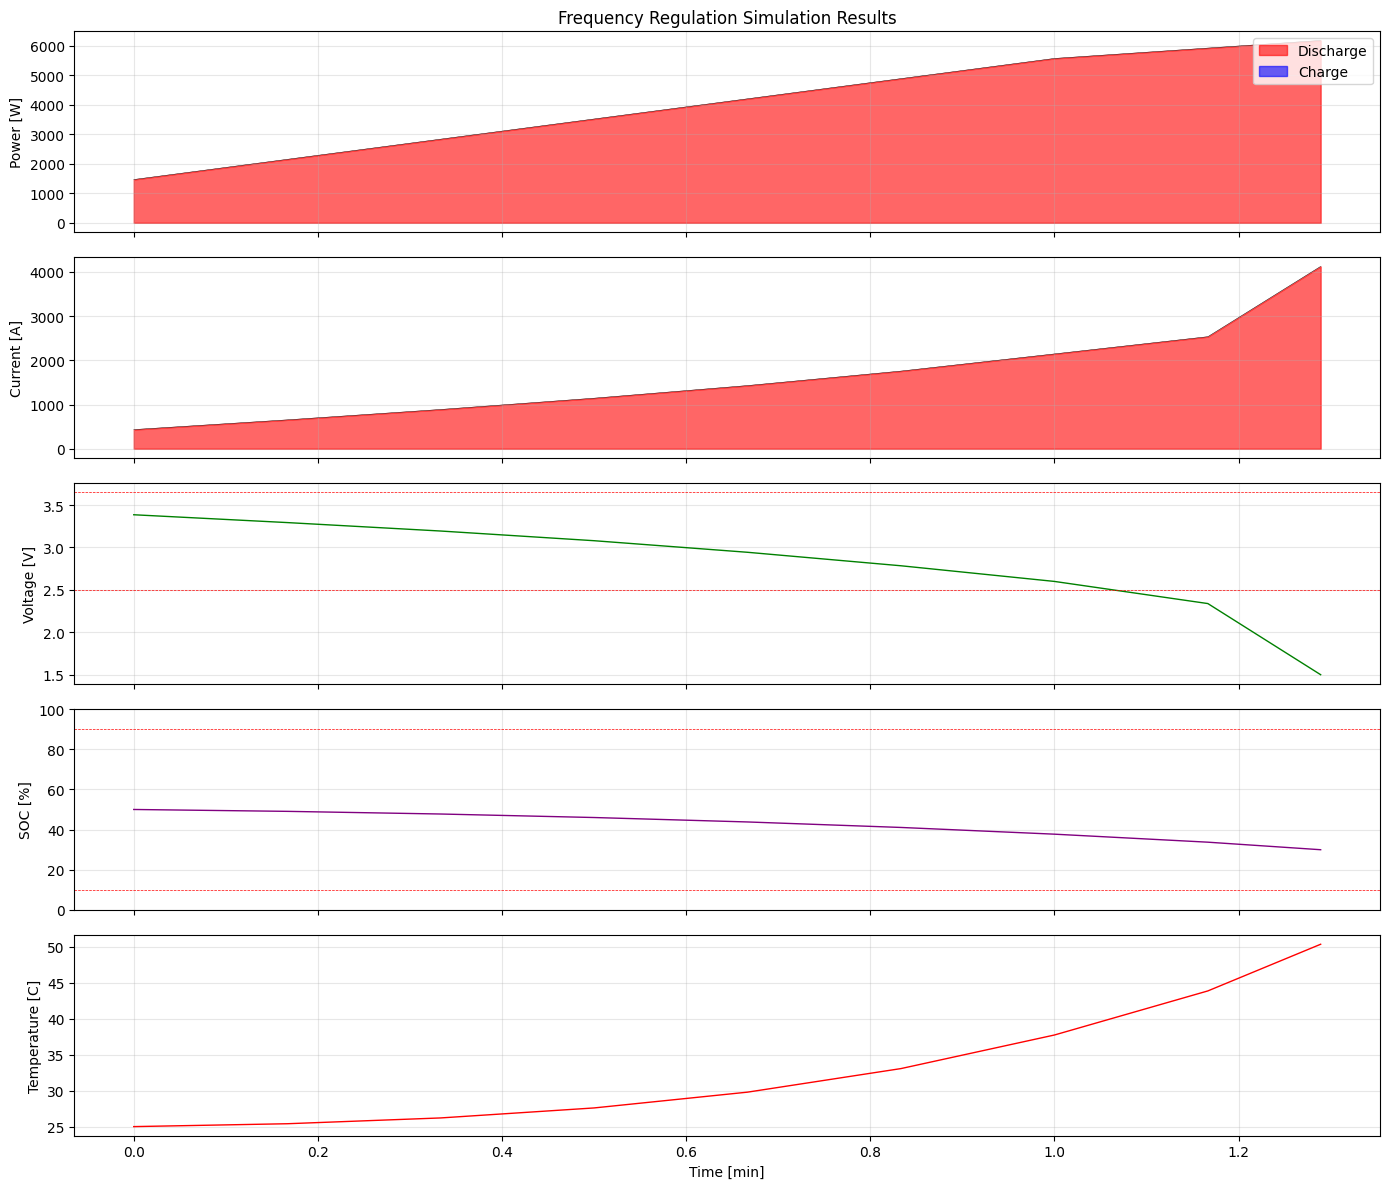

In [9]:
if result['success']:
    ts = result['timeseries']
    time_min = np.array(ts['time_s']) / 60
    
    fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
    
    # Power
    power = np.array(ts['power_W'])
    axes[0].fill_between(time_min, power, 0, where=(power >= 0), alpha=0.6, color='red', label='Discharge')
    axes[0].fill_between(time_min, power, 0, where=(power < 0), alpha=0.6, color='blue', label='Charge')
    axes[0].plot(time_min, power, 'k-', lw=0.3)
    axes[0].set_ylabel('Power [W]')
    axes[0].set_title(f'{selected_cycle} Simulation Results')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Current
    current = np.array(ts['current_A'])
    axes[1].fill_between(time_min, current, 0, where=(current >= 0), alpha=0.6, color='red')
    axes[1].fill_between(time_min, current, 0, where=(current < 0), alpha=0.6, color='blue')
    axes[1].plot(time_min, current, 'k-', lw=0.3)
    axes[1].set_ylabel('Current [A]')
    axes[1].grid(True, alpha=0.3)
    
    # Voltage
    axes[2].plot(time_min, ts['voltage_V'], 'g-', lw=1)
    axes[2].set_ylabel('Voltage [V]')
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=cell_design['upper_voltage_cutoff']['value'], color='r', ls='--', lw=0.5, label='Limits')
    axes[2].axhline(y=cell_design['lower_voltage_cutoff']['value'], color='r', ls='--', lw=0.5)
    
    # SOC
    if 'soc' in ts:
        axes[3].plot(time_min, np.array(ts['soc']) * 100, 'purple', lw=1)
        axes[3].set_ylabel('SOC [%]')
        axes[3].set_ylim(0, 100)
        axes[3].axhline(y=10, color='r', ls='--', lw=0.5)
        axes[3].axhline(y=90, color='r', ls='--', lw=0.5)
    else:
        # Estimate SOC from capacity
        cap = np.array(ts['capacity_Ah'])
        soc_est = config['initial_soc'] - cap / cell_capacity_Ah
        axes[3].plot(time_min, soc_est * 100, 'purple', lw=1)
        axes[3].set_ylabel('SOC [%] (est)')
    axes[3].grid(True, alpha=0.3)
    
    # Temperature
    axes[4].plot(time_min, np.array(ts['temperature_K']) - 273.15, 'r-', lw=1)
    axes[4].set_xlabel('Time [min]')
    axes[4].set_ylabel('Temperature [C]')
    axes[4].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 6. Energy Throughput Analysis

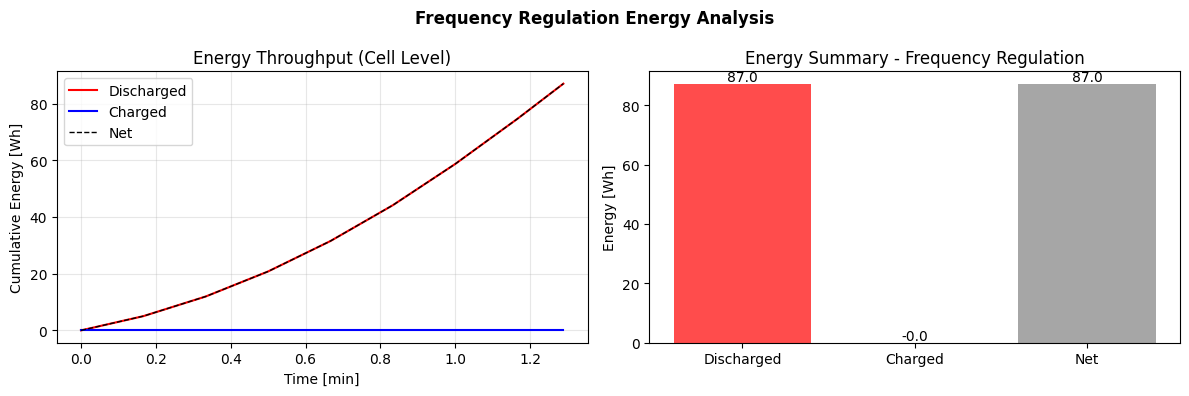


=== Pack-Level Energy Summary (125S32P) ===
Energy discharged: 2.78 kWh
Energy charged: 0.00 kWh
Net energy: 2.78 kWh
Round-trip efficiency: 0.0%


In [10]:
if result['success']:
    ts = result['timeseries']
    ea = result['energy_analysis']
    
    # Calculate cumulative energy
    time_s = np.array(ts['time_s'])
    power_W = np.array(ts['power_W'])
    
    dt = np.diff(time_s)
    power_mid = (power_W[:-1] + power_W[1:]) / 2
    energy_Wh = np.cumsum(power_mid * dt) / 3600
    energy_Wh = np.insert(energy_Wh, 0, 0)  # Start at 0
    
    # Separate charge and discharge
    discharge_energy = np.cumsum(np.where(power_mid > 0, power_mid * dt, 0)) / 3600
    charge_energy = np.cumsum(np.where(power_mid < 0, -power_mid * dt, 0)) / 3600
    discharge_energy = np.insert(discharge_energy, 0, 0)
    charge_energy = np.insert(charge_energy, 0, 0)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Cumulative energy
    axes[0].plot(time_s/60, discharge_energy, 'r-', lw=1.5, label='Discharged')
    axes[0].plot(time_s/60, charge_energy, 'b-', lw=1.5, label='Charged')
    axes[0].plot(time_s/60, energy_Wh, 'k--', lw=1, label='Net')
    axes[0].set_xlabel('Time [min]')
    axes[0].set_ylabel('Cumulative Energy [Wh]')
    axes[0].set_title('Energy Throughput (Cell Level)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Energy summary bar chart
    labels = ['Discharged', 'Charged', 'Net']
    values = [
        ea.get('energy_discharged_Wh', discharge_energy[-1]),
        ea.get('energy_regenerated_Wh', -charge_energy[-1]),
        ea.get('net_energy_Wh', energy_Wh[-1])
    ]
    colors = ['red', 'blue', 'gray']
    
    bars = axes[1].bar(labels, values, color=colors, alpha=0.7)
    axes[1].set_ylabel('Energy [Wh]')
    axes[1].set_title(f'Energy Summary - {selected_cycle}')
    axes[1].axhline(y=0, color='k', lw=0.5)
    
    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        axes[1].annotate(f'{val:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        ha='center', va='bottom' if height >= 0 else 'top')
    
    plt.suptitle(f'{selected_cycle} Energy Analysis', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print pack-level summary
    print(f"\n=== Pack-Level Energy Summary ({cells_series}S{cells_parallel}P) ===")
    print(f"Energy discharged: {discharge_energy[-1] * cells_parallel / 1000:.2f} kWh")
    print(f"Energy charged: {charge_energy[-1] * cells_parallel / 1000:.2f} kWh")
    print(f"Net energy: {energy_Wh[-1] * cells_parallel / 1000:.2f} kWh")
    print(f"Round-trip efficiency: {charge_energy[-1] / max(discharge_energy[-1], 0.001) * 100:.1f}%" if discharge_energy[-1] > 0 else "N/A (no discharge)")

## 7. Compare Multiple Duty Cycles

Run simulations for multiple BESS applications and compare results.

In [ ]:
# Select cycles to compare (ones that complete full hour)
cycles_to_compare = ["Peak Shaving", "Capacity Firming", "Energy Time Shifting"]
max_duration_min = 60  # 1 hour for comparison

comparison_results = {}

for cycle_name in cycles_to_compare:
    print(f"\nRunning {cycle_name}...")
    
    # Prepare data
    df = duty_cycles[cycle_name].copy()
    df = df[df['Time_Minutes'] <= max_duration_min].copy()
    
    time_s = df['Time_Minutes'].values * 60
    
    # Convert based on sign convention
    # PyBaMM: positive = discharge
    if cycle_name in cycles_with_discharge_positive:
        # Frequency Regulation: positive=discharge (same as PyBaMM)
        cell_power_W = df['Power_PerUnit'].values * max_power_kW * 1000 / cells_parallel
    else:
        # Other cycles: positive=charge (opposite of PyBaMM), negate
        cell_power_W = -df['Power_PerUnit'].values * max_power_kW * 1000 / cells_parallel
    
    # Standard 50% initial SOC for BESS
    initial_soc = 0.50
    
    # Config
    config = {
        "ambient_temperature": 298.15,
        "initial_temperature": 298.15,
        "initial_soc": initial_soc,
        "upper_voltage_cutoff": cell_design["upper_voltage_cutoff"]["value"],
        "lower_voltage_cutoff": cell_design["lower_voltage_cutoff"]["value"],
        "contact_resistance": 0.0001,
        "total_heat_transfer_coefficient": 15,
        "cooling_surface_area": 0.05,
        "period": "10 second",
        "min_soc": 0.10,
        "max_soc": 0.90,
        "drive_cycle": {
            "time_s": time_s,
            "power_W": cell_power_W,
            "label": cycle_name,
        },
    }
    
    result = run_drive_cycle(cell_design=cell_design, simulation_config=config)
    comparison_results[cycle_name] = result
    
    if result['success']:
        print(f"  Completed: {len(result['timeseries']['time_s'])} points")
    else:
        print(f"  Failed: {result.get('error', 'Unknown')}")

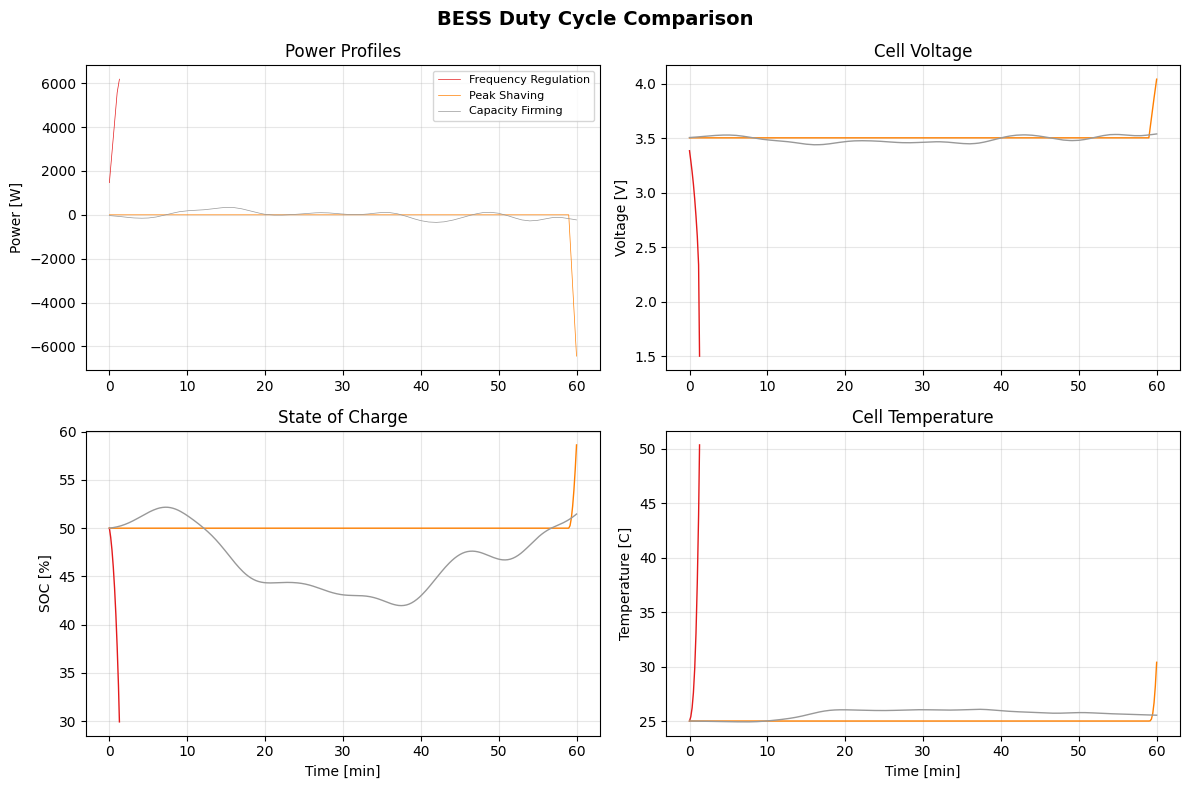

In [12]:
# Compare results
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

colors = plt.cm.Set1(np.linspace(0, 1, len(cycles_to_compare)))

for idx, (cycle_name, result) in enumerate(comparison_results.items()):
    if not result['success']:
        continue
    
    ts = result['timeseries']
    time_min = np.array(ts['time_s']) / 60
    color = colors[idx]
    
    # Power profiles
    axes[0, 0].plot(time_min, ts['power_W'], color=color, lw=0.5, label=cycle_name)
    
    # Voltage
    axes[0, 1].plot(time_min, ts['voltage_V'], color=color, lw=1, label=cycle_name)
    
    # SOC
    if 'soc' in ts:
        axes[1, 0].plot(time_min, np.array(ts['soc']) * 100, color=color, lw=1, label=cycle_name)
    
    # Temperature
    axes[1, 1].plot(time_min, np.array(ts['temperature_K']) - 273.15, color=color, lw=1, label=cycle_name)

axes[0, 0].set_ylabel('Power [W]')
axes[0, 0].set_title('Power Profiles')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_ylabel('Voltage [V]')
axes[0, 1].set_title('Cell Voltage')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_xlabel('Time [min]')
axes[1, 0].set_ylabel('SOC [%]')
axes[1, 0].set_title('State of Charge')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_xlabel('Time [min]')
axes[1, 1].set_ylabel('Temperature [C]')
axes[1, 1].set_title('Cell Temperature')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('BESS Duty Cycle Comparison', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# Summary table
summary_data = []

for cycle_name, result in comparison_results.items():
    if not result['success']:
        continue
    
    ts = result['timeseries']
    ea = result.get('energy_analysis', {})
    sm = result.get('summary', {})
    
    # Calculate energy metrics
    power_W = np.array(ts['power_W'])
    time_s = np.array(ts['time_s'])
    dt = np.diff(time_s)
    power_mid = (power_W[:-1] + power_W[1:]) / 2
    
    discharge_Wh = np.sum(power_mid[power_mid > 0] * dt[power_mid > 0]) / 3600
    charge_Wh = np.sum(-power_mid[power_mid < 0] * dt[power_mid < 0]) / 3600
    
    temp_K = np.array(ts['temperature_K'])
    
    summary_data.append({
        'Duty Cycle': cycle_name,
        'Duration [min]': time_s[-1] / 60,
        'Energy Discharged [Wh]': discharge_Wh,
        'Energy Charged [Wh]': charge_Wh,
        'Net Energy [Wh]': discharge_Wh - charge_Wh,
        'Temp Rise [C]': temp_K.max() - temp_K[0],
        'Max Temp [C]': temp_K.max() - 273.15,
    })

summary_df = pd.DataFrame(summary_data)
print("\n=== BESS Duty Cycle Comparison (Cell Level) ===")
print(summary_df.to_string(index=False))


=== BESS Duty Cycle Comparison (Cell Level) ===
          Duty Cycle  Duration [min]  Energy Discharged [Wh]  Energy Charged [Wh]  Net Energy [Wh]  Temp Rise [C]  Max Temp [C]
Frequency Regulation         1.28921            8.701862e+01             0.000000        87.018621      25.362193     50.362193
        Peak Shaving        60.00000            3.331546e-14            53.699451       -53.699451       5.395201     30.395201
    Capacity Firming        60.00000            6.223969e+01            71.623671        -9.383978       1.077425     26.077425


## 8. Conclusions

Key observations from BESS duty cycle simulations:

1. **Frequency Regulation**: High cycling intensity with rapid charge/discharge transitions. Important for cell cycle life.

2. **Peak Shaving**: Lower cycling frequency with concentrated discharge events. Lower thermal stress.

3. **Capacity Firming**: Irregular cycling patterns following solar variability. Shallow depth of discharge.

The Tesla Model 3 LFP cell is well-suited for BESS applications due to:
- High cycle life (LFP chemistry)
- Flat voltage profile (good for grid applications)
- Good thermal stability
- Large capacity (161 Ah) reduces parallel connections